In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns 
from scipy.stats import spearmanr


In [2]:
film_set = pd.read_csv("film_df.csv")
film_set.head()

,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes,title,region,language,isOriginalTitle,english_grammar_signal,era,log_numVotes
0,tt0069204,movie,Sabse Bada Sukh,1972,114.0,"Comedy,Drama",6.0,21,Subse Bada Sukh,IN,bn,0,False,Classics,1.342423
1,tt0070047,movie,The Exorcist,1973,122.0,Horror,8.1,493902,The Exorcist,IN,bn,0,True,Classics,5.693642
2,tt0070047,movie,The Exorcist,1973,122.0,Horror,8.1,493902,Shoitan Raat,IN,bn,0,True,Classics,5.693642
3,tt0073191,movie,Jai Santoshi Maa,1975,145.0,"Drama,Fantasy",6.6,242,Joy Sontoshi Maa,IN,bn,0,False,Classics,2.385606
4,tt0078170,movie,Roads to the South,1978,100.0,Drama,5.5,291,Putevi na Jug,BD,bn,0,True,Classics,2.465383


In [3]:
film_set[['startYear', 'era', 'numVotes', 'log_numVotes']].describe()

,startYear,numVotes,log_numVotes
count,269.000000,2.690000e+02,269.000000
mean,2005.721190,5.062871e+04,2.668803
std,15.532836,1.760129e+05,1.380119
min,1970.000000,6.000000e+00,0.845098
25%,1992.000000,3.300000e+01,1.531479
50%,2011.000000,2.500000e+02,2.399674
75%,2018.000000,2.188000e+03,3.340246
max,2025.000000,1.670175e+06,6.222762


Splitting the set into Classics and Moderns

In [4]:
classic_films = film_set[film_set['era'] == 'Classics']
modern_films = film_set[film_set['era'] == 'Modern']
classic_films.head()

,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes,title,region,language,isOriginalTitle,english_grammar_signal,era,log_numVotes
0,tt0069204,movie,Sabse Bada Sukh,1972,114.0,"Comedy,Drama",6.0,21,Subse Bada Sukh,IN,bn,0,False,Classics,1.342423
1,tt0070047,movie,The Exorcist,1973,122.0,Horror,8.1,493902,The Exorcist,IN,bn,0,True,Classics,5.693642
2,tt0070047,movie,The Exorcist,1973,122.0,Horror,8.1,493902,Shoitan Raat,IN,bn,0,True,Classics,5.693642
3,tt0073191,movie,Jai Santoshi Maa,1975,145.0,"Drama,Fantasy",6.6,242,Joy Sontoshi Maa,IN,bn,0,False,Classics,2.385606
4,tt0078170,movie,Roads to the South,1978,100.0,Drama,5.5,291,Putevi na Jug,BD,bn,0,True,Classics,2.465383


[Q1] Plotting numVotes as proxies for Viewer Counts against Eras to identify Cultural Trends.

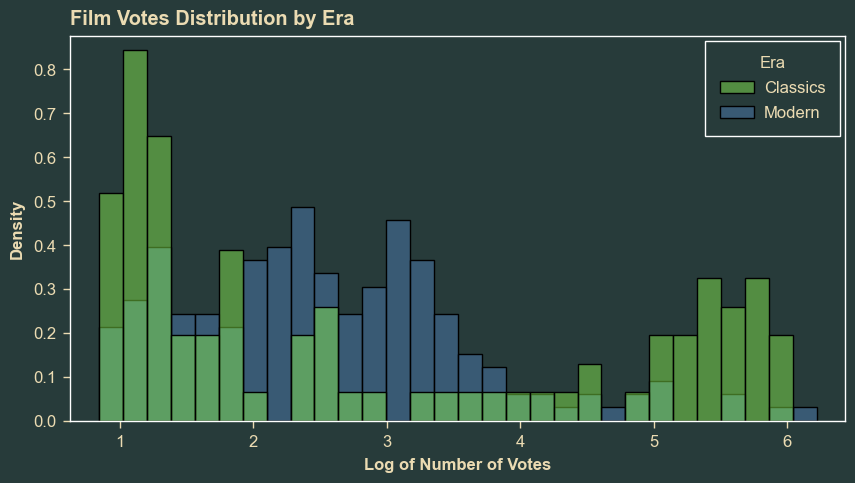

In [5]:
from aquarel import load_theme
white_shades = ["#8AF34D", "#4F81BD"]
theme = load_theme("gruvbox_dark").set_overrides({
    "figure.facecolor": "#273B3A",
    "axes.facecolor": "#273B3A",
    "grid.color": "#FFFFFF",
    "axes.edgecolor": "#FFFFFF"
})
with theme:
    fig, ax = plt.subplots(figsize=(10,5))
    sns.histplot(
        data=film_set,
        x="log_numVotes",
        hue="era",
        palette=white_shades,
        bins=30,
        stat="density",
        common_norm=False,
        alpha = 0.45,
        ax = ax
    )
    legend = ax.get_legend()
    legend.set_title("Era")
    legend.set_frame_on(True)
    legend.get_frame().set_boxstyle('Square')
    legend.get_frame().set_facecolor("#273B3A")
    legend.get_frame().set_edgecolor("white")
    legend.get_frame().set_alpha(1)
    patches = ax.patches
    half = len(patches) // 2
    for patch in patches[half:]:
        patch.set_edgecolor("#000000")
        patch.set_linewidth(1)
    plt.title("Film Votes Distribution by Era", loc='left', fontweight='bold')
    plt.xlabel("Log of Number of Votes",fontweight='bold')
    plt.ylabel("Density",fontweight='bold')
    
plt.show()

[Q2] Yearly Median Tables to identify long term changes in Engagement Trends.

In [6]:
yearly = (
    film_set.groupby(['era','startYear'])['log_numVotes'].median().reset_index().sort_values('startYear')
)
yearly['rolling_median'] = (
    yearly.groupby('era')['log_numVotes'].transform(lambda x: x.rolling(3, min_periods=1).median())
)

Plotting it:

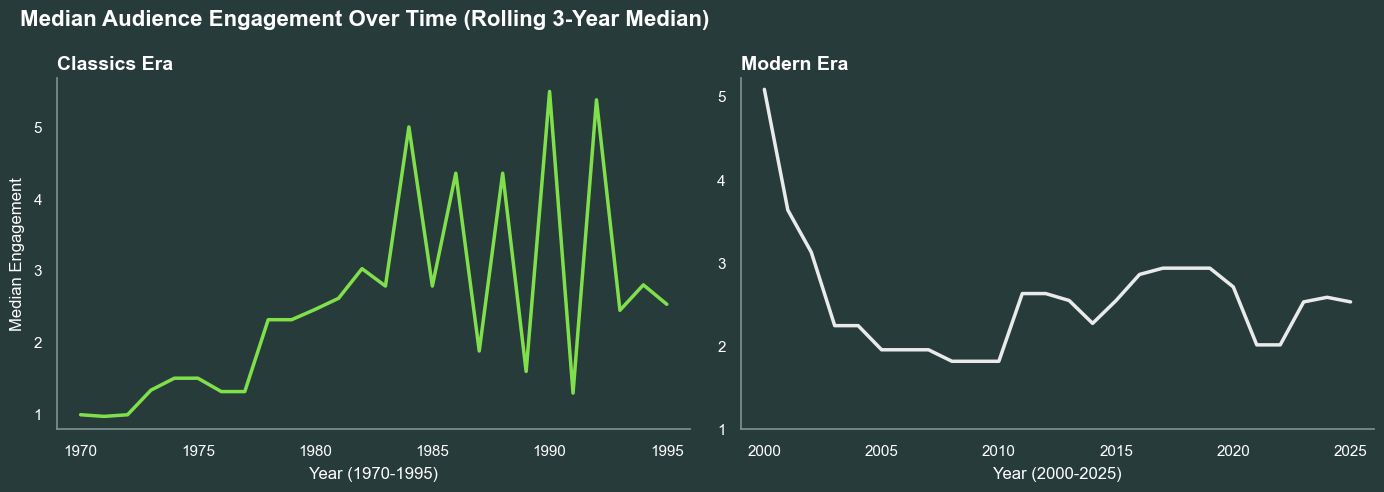

In [7]:
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.facecolor": "#273B3A",
        "figure.facecolor": "#273B3A",

        "grid.color": "#4A5C5B",
        "grid.alpha": 0.12,

        "axes.edgecolor": "#7C908F",

        "text.color": "white",
        "axes.labelcolor": "white",
        "xtick.color": "white",
        "ytick.color": "white"
    }
)

classic = yearly[yearly["era"] == "Classics"]
modern = yearly[yearly["era"] == "Modern"]

fig, axes = plt.subplots(
    1,2,
    figsize = (14, 5),
    sharey= False
)

fig.patch.set_facecolor("#273B3A")
colors = {
    "Classics" : "#8AF34D",
    "Modern" : "#FFFFFF"
}

#CLASSICS
ax = axes[0]
ax.set_facecolor("#273B3A")
sns.lineplot(
    data=classic,
    x="startYear",
    y="rolling_median",
    linewidth=2.5,
    color=colors["Classics"],
    alpha=0.9,
    ax=ax
)
ax.set_yticks(range(1, 6))
ax.set_title("Classics Era", color="white", fontsize=14, weight="semibold",loc="left",pad=6)
ax.set_xlabel("Year (1970-1995)", color="white")
ax.set_ylabel("Median Engagement", color="white")

# Styling
ax.tick_params(colors="white")
ax.grid(False)

sns.despine(ax=ax)


# ---------- MODERN ----------
ax = axes[1]

ax.set_facecolor("#273B3A")

sns.lineplot(
    data=modern,
    x="startYear",
    y="rolling_median",
    linewidth=2.5,
    color=colors["Modern"],
    alpha=0.9,
    ax=ax
)
ax.set_yticks(range(1, 6))
ax.set_title("Modern Era", color="white", fontsize=14, weight="semibold",loc="left",pad=6)
ax.set_xlabel("Year (2000-2025)", color="white")
ax.set_ylabel("")

# Styling
ax.tick_params(colors="white")
ax.grid(False)

sns.despine(ax=ax)

# Main title
fig.suptitle(
    "Median Audience Engagement Over Time (Rolling 3-Year Median)",
    color="white",
    fontsize=16,
    weight="semibold",
    x=0.02,
    ha="left"
)

plt.tight_layout()
plt.subplots_adjust(wspace=0.08)
plt.show()

[PREPARATION OF GENRE COUNTS FOR TOP 3 GENRES ALONGSIDE Top 5 GENRES IN BOTH ERAS]

In [11]:
genre_set = (
    film_set.dropna(subset=["genres"]).assign(genres=film_set["genres"].str.split(",")).explode("genres")
)
genre_counts = (
    genre_set.groupby(["era","genres"]).size().reset_index(name="count")
)
genre_counts["share"] = (
    genre_counts.groupby("era")["count"].transform(lambda x: x/x.sum())
)
genre_counts_sorted = (
    genre_counts.sort_values(["era","share"], ascending=[True, False])
)
genre_counts_sorted.groupby("era").head()

,era,genres,count,share
4,Classics,Drama,68,0.412121
0,Classics,Action,22,0.133333
12,Classics,Romance,18,0.109091
2,Classics,Comedy,12,0.072727
3,Classics,Crime,11,0.066667
20,Modern,Drama,129,0.363380
14,Modern,Action,52,0.146479
28,Modern,Romance,31,0.087324
17,Modern,Comedy,22,0.061972
30,Modern,Thriller,18,0.050704


[TOP 3 GENRES]

In [12]:
top_three_set = (
    genre_counts_sorted.groupby("era").head(3).groupby("era")["share"].sum()
)
print(top_three_set)

era
Classics    0.654545
Modern      0.597183
Name: share, dtype: float64


[SHANNON ENTROPY CALCULATION]

In [13]:
shannon_entropy = (
    genre_counts.groupby("era")["share"]
    .apply(lambda x: -(x * np.log2(x)).sum())
)
summary_table = pd.DataFrame({
    "Top-3 Genre Share": top_three_set,
    "Shannon Entropy": shannon_entropy
})
summary_table["Top-3 Genre Share"] = (
    summary_table["Top-3 Genre Share"] * 100
).round(2)

summary_table["Shannon Entropy"] = (
    summary_table["Shannon Entropy"]
).round(2)

print(summary_table)
print(shannon_entropy)

          Top-3 Genre Share  Shannon Entropy
era                                         
Classics              65.45             2.86
Modern                59.72             3.24
era
Classics    2.862041
Modern      3.236225
Name: share, dtype: float64


[Q3] Top 5 Genres Plot Preparation, for identification of Genre Distribution across two eras:

In [14]:
# Get top 5 genres overall (across both eras combined)
top_genres = (
    genre_counts.groupby("genres")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Filter original dataframe to only those genres
top_five_set = (
    genre_counts[genre_counts["genres"].isin(top_genres)]
)

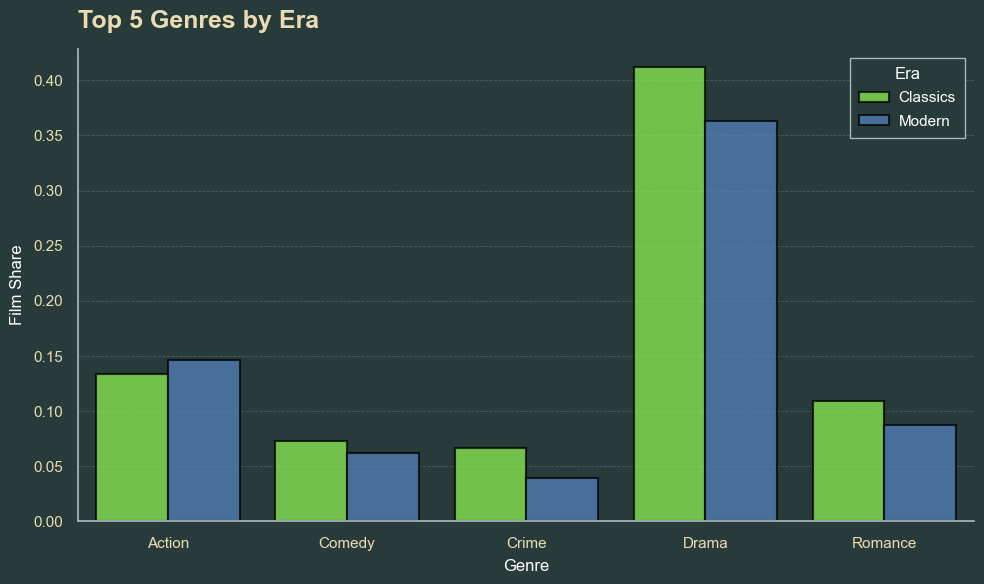

In [15]:
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=top_five_set,
    x="genres",
    y="share",
    hue="era",
    palette={
        "Classics": "#8AF34D",
        "Modern": "#4F81BD"
    },
    edgecolor = "black",
    linewidth=1.5,
    saturation=0.95,
    alpha= 0.75,
    ax=ax
)

# Background
ax.set_facecolor("#273B3A")
fig.patch.set_facecolor("#273B3A")

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.18
)

ax.set_axisbelow(True)

# Remove unnecessary spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Keep subtle remaining spines
ax.spines["left"].set_color("#AAB7B8")
ax.spines["bottom"].set_color("#AAB7B8")

# Labels
plt.title(
    "Top 5 Genres by Era",
    loc="left",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Genre", fontsize=12)
plt.ylabel("Film Share", fontsize=12)

plt.xticks(rotation=0)

# Legend styling
legend = plt.legend(
    title="Era",
    frameon=True,
    fancybox=False,
    framealpha=1
)

legend.get_frame().set_facecolor("#273B3A")
legend.get_frame().set_edgecolor("#AAB7B8")


plt.tight_layout()
plt.show()

[Q4] Correlation between Audience Ratings & Number of Votes to identify the relation between Quality and Audience Reach.

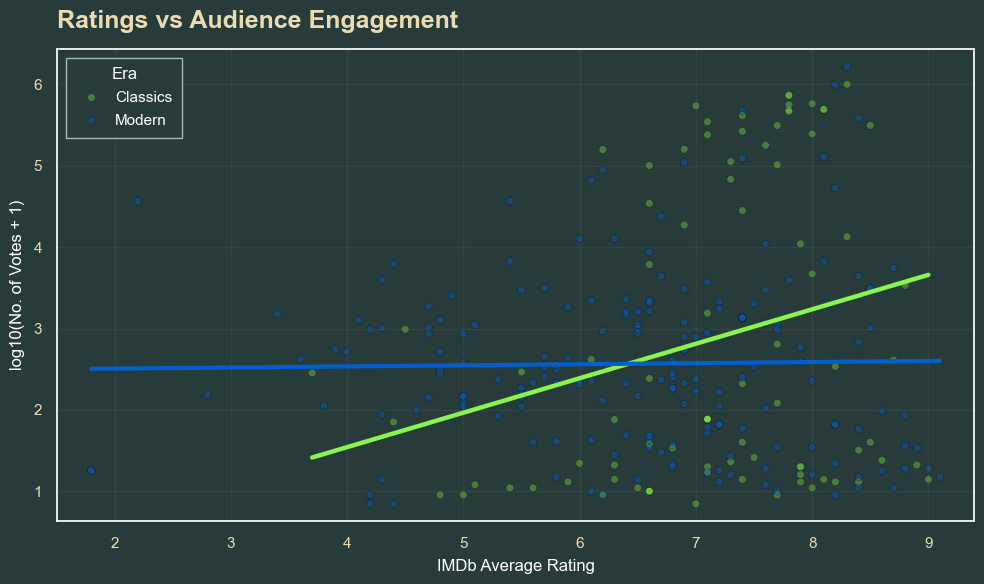

In [16]:
bg_color = "#273B3A"

fig, ax = plt.subplots(figsize=(10,6))

fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Scatterplot layer
sns.scatterplot(
    data=film_set,
    x="averageRating",
    y="log_numVotes",
    hue="era",
    palette=["#8AF34D","#045FCE"],
    alpha=0.35,
    edgecolor="#000000",
    s=30
)

# Regression line for Classics
sns.regplot(
    data=film_set[film_set["era"] == "Classics"],
    x="averageRating",
    y="log_numVotes",
    scatter=False,
    ci=None,
    color="#8AF34D",
    line_kws={"linewidth": 3.2}
)

# Regression line for Modern
sns.regplot(
    data=film_set[film_set["era"] == "Modern"],
    x="averageRating",
    y="log_numVotes",
    scatter=False,
    ci=None,
    color="#045FCE",
    line_kws={"linewidth": 3.0}
)

plt.title("Ratings vs Audience Engagement",loc="left",fontsize=18,
    fontweight="bold",
    pad=15
)
plt.xlabel("IMDb Average Rating")
plt.ylabel("log10(No. of Votes + 1)")

plt.grid(alpha=0.05)
legend = plt.legend(
    title="Era",
    frameon=True,
    fancybox=False,
    framealpha=1
)

legend.get_frame().set_facecolor("#273B3A")
legend.get_frame().set_edgecolor("#AAB7B8")

plt.tight_layout()
plt.show()

Focusing on a Spearman Correlation Next, to ensure a correlation coefficient. Ranks are used here instead of raw data to act against Outliers.

In [18]:
for era in ["Classics","Modern"]:
    subset = film_set[film_set["era"] == era]
    corr, p = spearmanr(subset["averageRating"], subset["log_numVotes"])
    print(f"{era}: Spearman r = {corr:.3f}")

Classics: Spearman r = 0.271
Modern: Spearman r = -0.048


[Q5] How unevenly is attention distributed? Computed via the Gini Coefficient.

In [20]:
import numpy as np
def gini(x):
    x = np.array(x)
    x = x[x>=0]
    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n+1)
    return (np.sum((2*index-n-1)*x))/(n*np.sum(x))

for era in ['Classics','Modern']:
    subset = film_set[film_set['era'] == era]
    g = gini(subset['numVotes'])
    print (f"{era} Gini: {g:.3f}")

Classics Gini: 0.810
Modern Gini: 0.960
